# CheMeleon + Mother Standalone Heads

**Goal:** Use a pretrained molecular foundation model ([CheMeleon](https://github.com/chemprop/chemprop)) to
extract 2 048-dimensional molecular fingerprints, then plug them straight into
Mother's lightweight standalone heads for property prediction **with uncertainty
estimation**.

```
                        ┌──────────────────────────────────┐
  SMILES                │         CheMeleon                │
  "CCO"  ──────────►    │  Bond-Message-Passing Network    │
  "c1ccccc1"            │  (depth=6, d_h=2048, pretrained) │
                        └──────────────┬───────────────────┘
                                       │
                                       ▼
                               Fingerprints  (n, 2048)
                                       │
                    ┌──────────────────┼──────────────────┐
                    ▼                  ▼                  ▼
             ┌────────────┐   ┌──────────────┐   ┌──────────────┐
             │MLPHead     │   │FlowHead      │   │ NODERegressor│
             │Regressor   │   │Regressor     │   │ (+ MLP head) │
             │            │   │              │   │              │
             │ ŷ ∈ ℝ      │   │ p(y|x)       │   │ Trees → MLP  │
             │ + MC σ     │   │ + NLL σ      │   │ + MC σ       │
             └────────────┘   └──────────────┘   └──────────────┘
```

| Component | Role |
|---|---|
| **CheMeleon** | Pretrained Bond-Message-Passing Network (d_h = 2048, depth = 6). Converts SMILES → fixed-length molecular embeddings. |
| **MLPHeadRegressor** | Fast MLP head with MC-Dropout uncertainty (epistemic). |
| **FlowHeadRegressor** | Normalising-flow head that models the full p(y|x) distribution (aleatoric + epistemic). |

> **Why standalone heads?**  They accept any `(n, d)` NumPy / pandas feature
> matrix, so you can swap CheMeleon for **any** featuriser (Morgan FPs, Uni-Mol,
> MolBERT, …) without touching the downstream code.

## 1 — Import Required Libraries

In [1]:
import warnings

warnings.filterwarnings("ignore")  # suppress rdkit / numpy ABI noise

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from mother.feature_generation import CheMeleonFingerprintFactory
from mother.ml.models.m_heads import FlowHeadRegressor, MLPHeadRegressor

## 2 — Create CheMeleon Fingerprint Factory

`CheMeleonFingerprintFactory` from `mother.feature_generation` handles
everything: downloading the pretrained checkpoint on first use, loading the
architecture + weights, and building a scikit-learn compatible transformer.


In [2]:
factory = CheMeleonFingerprintFactory()
fingerprinter = factory.get_fingerprint_generator()

print(f"✓ CheMeleon fingerprint generator ready  (output dim: {factory.fpSize})")

✓ CheMeleon fingerprint generator ready  (output dim: 2048)


## 3 — Load the FreeSolv Dataset

[FreeSolv](https://github.com/MobleyLab/FreeSolv) contains **experimental
hydration free energies** (ΔG_hydr in kcal/mol).  We use the 50-molecule
training subset shipped with Mother's examples.


In [3]:
df = pd.read_csv("../freesolv_train.csv")
smiles = df["smiles"].tolist()
targets = df["expt"].values.astype(np.float32)

print(f"Dataset: {len(df)} molecules")
df[["iupac", "smiles", "expt"]].head(10)

Dataset: 50 molecules


,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21
5,"3,5-dimethylphenol",Cc1cc(cc(c1)O)C,-6.27
6,"2,3-dimethylbutane",CC(C)C(C)C,2.34
7,2-methylpentan-2-ol,CCCC(C)(C)O,-3.92
8,"1,2-dimethylcyclohexane",C[C@@H]1CCCC[C@@H]1C,1.58
9,butan-2-ol,CC[C@H](C)O,-4.62


## 4 — Extract CheMeleon Fingerprints

Now we simply `fit_transform` the SMILES through our transformer.


In [4]:
fingerprints = fingerprinter.fit_transform(smiles)
print(f"✓ Fingerprint matrix shape: {fingerprints.shape}")  # (50, 2048)

✓ Fingerprint matrix shape: (50, 2048)


## 5 — Train / Test Split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(fingerprints, targets, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} molecules, Test: {X_test.shape[0]} molecules")
print(f"Feature dim: {X_train.shape[1]}")

Train: 40 molecules, Test: 10 molecules
Feature dim: 2048


---

## 6 — MLPHeadRegressor: Training

Mother's `MLPHeadRegressor` wraps a standard MLP with:
- **Automatic dimension detection** — no need to pass `input_dim`; a Skorch
  callback reads it from the first batch.
- **Early stopping & LR scheduling** — sensible defaults out of the box.
- **MC-Dropout uncertainty** via `predict_uncertainty()`.

```
  CheMeleon fingerprint (2048-d)
        │
        ▼
  ┌─────────────────────────────────────────┐
  │  Linear(2048 → 512) → BN → ReLU → Drop │
  │  Linear(512  → 256) → BN → ReLU → Drop │
  │  Linear(256  → 128) → BN → ReLU → Drop │
  │  Linear(128  →   1)                     │
  └─────────────────────┬───────────────────┘
                        │
                        ▼
                  ΔG_hydr (kcal/mol)
```

Training minimises the MSE loss:  
$\mathcal{L}_{\text{MLP}} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$


In [6]:
mlp = MLPHeadRegressor(
    hidden_dims=[512, 256, 128],
    dropout=0.10,
    max_epochs=300,
    lr=0.003,
)
mlp.fit(X_train, y_train)

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1       56.1846       38.3025  0.0030  0.4247
      2       43.0360       38.8912  0.0030  0.0169
      3       36.9558       39.0394  0.0030  0.0153
      4       31.9964       39.0155  0.0030  0.0164
      5       27.6131       38.7575  0.0030  0.0181
      6       24.6593       38.5375  0.0030  0.0162
      7       22.7049       38.1963  0.0030  0.0162
      8       21.5265       37.8646  0.0030  0.0186
      9       16.9989       36.9782  0.0030  0.0208
     10       16.2111       36.0432  0.0030  0.0221
     11       15.0166 

<class 'mother.ml.models.m_heads.MLPHeadRegressor'>[initialized](
  module_=MLPHead(
    (mlp): Sequential(
      (0): Linear(in_features=2048, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=128, out_features=1, bias=True)
    )
  ),
)

### 6.1 — Evaluate MLP Predictions


In [7]:
y_pred_mlp = mlp.predict(X_test)
rmse_mlp = root_mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
print(f"MLP Head — RMSE: {rmse_mlp:.3f} kcal/mol,  R²: {r2_mlp:.3f}")

MLP Head — RMSE: 2.089 kcal/mol,  R²: 0.496


### 6.2 — Uncertainty Estimation (MC Dropout)

`predict_uncertainty()` enables dropout at inference time and draws
`n_samples` stochastic forward passes.  The standard deviation across passes is
reported as **knowledge (epistemic) uncertainty**.

```
                          Same input x
                              │
        ┌─────────────────────┼─────────────────────┐
        ▼                     ▼                     ▼
  MLP (mask θ₁)        MLP (mask θ₂)   ...   MLP (mask θₙ)
        │                     │                     │
        ▼                     ▼                     ▼
       ŷ₁                   ŷ₂         ...        ŷₙ
        └─────────────────────┼─────────────────────┘
                              │
                    mean = (1/N) Σ ŷᵢ
                    σ    = std(ŷ₁ … ŷₙ)   ← epistemic uncertainty
```

$\hat{y} = \frac{1}{N}\sum_{i=1}^{N} f_{\theta_i}(x) \qquad \sigma_{\text{MC}} = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(f_{\theta_i}(x) - \hat{y})^2}$


In [8]:
unc_mlp = mlp.predict_uncertainty(X_test, n_samples=100)
unc_mlp

,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-5.812479,0.508935,None,None
1,2.693925,0.478613,None,None
2,-2.709276,0.460961,None,None
3,-4.053767,0.405229,None,None
4,-8.976756,0.642943,None,None
5,-3.148004,0.467862,None,None
6,-5.830154,0.546348,None,None
7,-1.216735,0.317282,None,None
8,-12.916821,0.790539,None,None
9,1.510795,0.436720,None,None


### 6.3 — Visualise: Parity Plot & Uncertainty vs Error


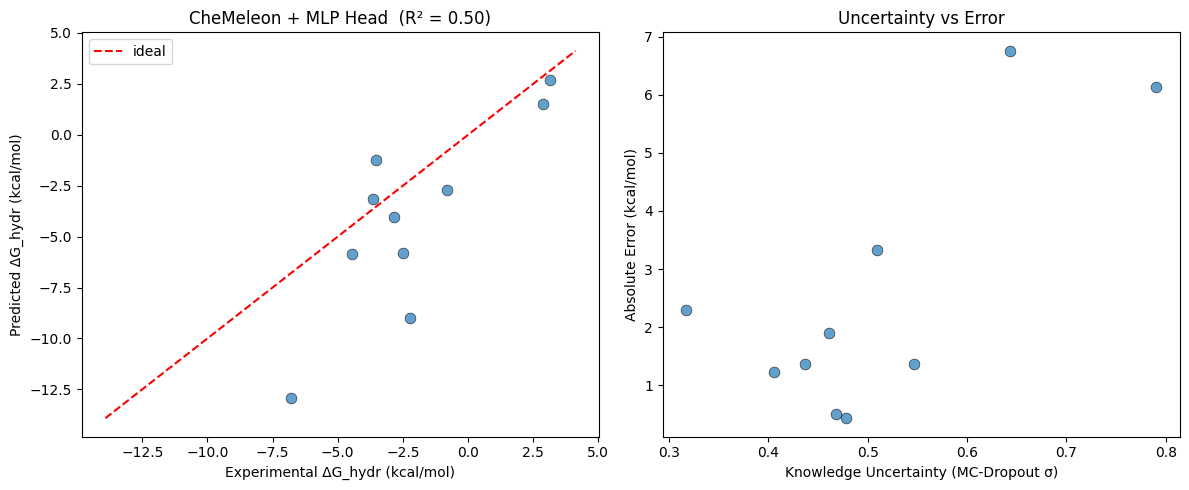

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Parity plot ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, unc_mlp["mean_predictions"], alpha=0.7, edgecolors="k", linewidths=0.5, s=60)
lims = [
    min(y_test.min(), unc_mlp["mean_predictions"].min()) - 1,
    max(y_test.max(), unc_mlp["mean_predictions"].max()) + 1,
]
ax.plot(lims, lims, "r--", lw=1.5, label="ideal")
ax.set_xlabel("Experimental ΔG_hydr (kcal/mol)")
ax.set_ylabel("Predicted ΔG_hydr (kcal/mol)")
ax.set_title(f"CheMeleon + MLP Head  (R² = {r2_mlp:.2f})")
ax.legend()

# ── Uncertainty vs absolute error ────────────────────────────
ax = axes[1]
errors = np.abs(y_test - unc_mlp["mean_predictions"].values)
ax.scatter(unc_mlp["knowledge_uncertainty"], errors, alpha=0.7, edgecolors="k", linewidths=0.5, s=60)
ax.set_xlabel("Knowledge Uncertainty (MC-Dropout σ)")
ax.set_ylabel("Absolute Error (kcal/mol)")
ax.set_title("Uncertainty vs Error")

plt.tight_layout()
plt.show()

---

## 6½ — NODE vs MLP Head: Side-by-Side Comparison

Mother's **NODERegressor** (Neural Oblivious Decision Ensembles) is a full
tree-based deep-learning model.  Here we feed it the same CheMeleon
fingerprints and compare against the lightweight standalone MLP head.

| | **NODERegressor** | **MLPHeadRegressor** |
|---|---|---|
| Architecture | Differentiable oblivious decision trees + head | Simple MLP |
| Parameters | `num_trees`, `depth`, `num_layers`, `head_type` | `hidden_dims`, `dropout` |
| Uncertainty | MC Dropout + optional Flow head | MC Dropout |
| Weight | Heavy (many trees) | Lightweight |


In [10]:
from mother.ml.models.m_node import NODERegressor

# Use a small NODE — CheMeleon already provides rich features so we
# don't need a huge tree ensemble on top.
node = NODERegressor(
    num_trees=512,
    depth=4,
    num_layers=1,
    head_type="mlp",
    mlp_hidden_dims=[128, 64],
    mlp_dropout=0.10,
    input_dropout=0.05,
    max_epochs=100,
    lr=0.005,
    batch_size=32,
)
node.fit(X_train, y_train)

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1       40.2371  6.4563
      2       29.4811  2.4993
      3       23.7538  2.3791
      4       19.7768  2.5069
      5       16.9247  2.4639
      6       14.2184  2.2755
      7       13.0186  2.2939
      8        8.4418  2.2408
      9        6.5619  2.2024
     10        7.5567  2.1321
     11        5.2736  2.1221
     12        3.5284  2.1820
     13        3.0531  2.1199
     14        2.1696  2.1406
     15        1.3624  2.1570
     16        1.4849  2.1189
     17        1.7216  2.2983
     18        1.9775  2.0889
     19        0.9023  2.1108
     20        2.0653  2.0992
     21        2.3595  2.2294
     22        3.5531  2.3455
     23        2.0495  2.0633
     24        1.7460  2.1742
     25        2.6245  2.0485
     26  

<class 'mother.ml.models.m_node.NODERegressor'>[initialized](
  module_=CompletePyTorchTabularNODE(
    (dense_block): DenseODSTBlock(
      (0): ODST(in_features=2048, num_trees=512, depth=4, tree_dim=4, flatten_output=True)
    )
    (embedding_layer): Embedding1dLayer()
    (head): MLPHead(
      (mlp): Sequential(
        (0): Linear(in_features=2048, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout(p=0.1, inplace=False)
        (8): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  ),
)

In [11]:
y_pred_node = node.predict(X_test)
rmse_node = root_mean_squared_error(y_test, y_pred_node)
r2_node = r2_score(y_test, y_pred_node)
print(f"NODE       — RMSE: {rmse_node:.3f} kcal/mol,  R²: {r2_node:.3f}")
print(f"MLP Head   — RMSE: {rmse_mlp:.3f} kcal/mol,  R²: {r2_mlp:.3f}")

NODE       — RMSE: 1.983 kcal/mol,  R²: 0.545
MLP Head   — RMSE: 2.089 kcal/mol,  R²: 0.496


### 6½.1 — NODE Uncertainty


In [12]:
unc_node = node.predict_uncertainty(X_test, num_samples=100)
unc_node

,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-0.583607,0.447032,None,0.447032
1,2.107568,0.356979,None,0.356979
2,-0.614289,0.527626,None,0.527626
3,-1.030094,0.445530,None,0.445530
4,-2.705900,0.833130,None,0.833130
5,-0.601548,0.428673,None,0.428673
6,-4.882439,0.928996,None,0.928996
7,0.204908,0.371389,None,0.371389
8,-4.503162,0.956990,None,0.956990
9,1.266629,0.419111,None,0.419111


### 6½.2 — Visual Comparison: NODE vs MLP Head


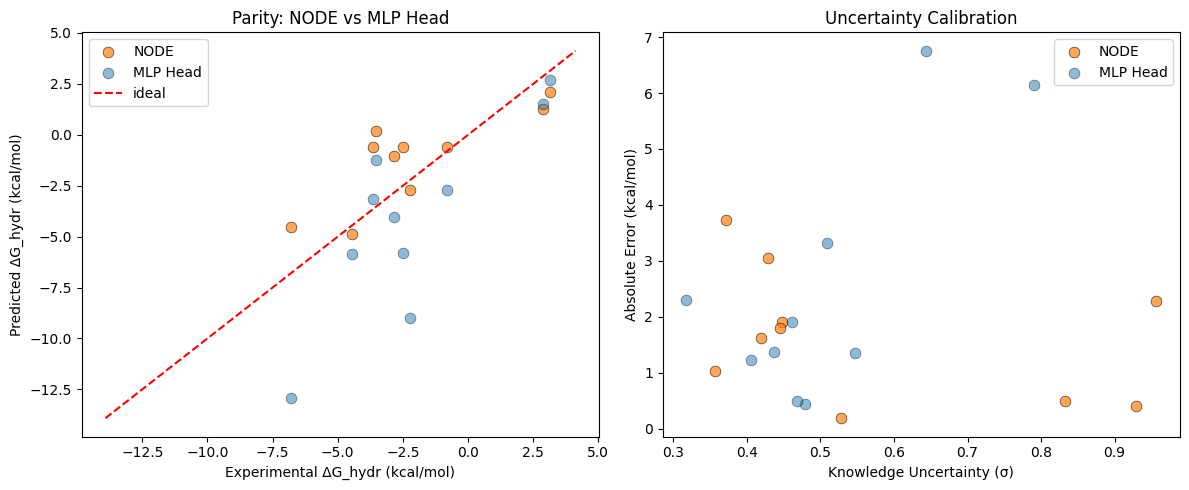

,Model,RMSE,R²,Mean σ
0,MLPHeadRegressor,2.089,0.496,0.506
1,NODERegressor,1.983,0.545,0.572


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── NODE parity ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(
    y_test,
    unc_node["mean_predictions"],
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:orange",
    label="NODE",
)
ax.scatter(
    y_test,
    unc_mlp["mean_predictions"],
    alpha=0.5,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:blue",
    label="MLP Head",
)
all_vals = np.concatenate([y_test, unc_node["mean_predictions"].values, unc_mlp["mean_predictions"].values])
lims = [all_vals.min() - 1, all_vals.max() + 1]
ax.plot(lims, lims, "r--", lw=1.5, label="ideal")
ax.set_xlabel("Experimental ΔG_hydr (kcal/mol)")
ax.set_ylabel("Predicted ΔG_hydr (kcal/mol)")
ax.set_title("Parity: NODE vs MLP Head")
ax.legend()

# ── Uncertainty comparison ───────────────────────────────────
ax = axes[1]
errors_node = np.abs(y_test - unc_node["mean_predictions"].values)
errors_mlp = np.abs(y_test - unc_mlp["mean_predictions"].values)
ax.scatter(
    unc_node["knowledge_uncertainty"],
    errors_node,
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:orange",
    label="NODE",
)
ax.scatter(
    unc_mlp["knowledge_uncertainty"],
    errors_mlp,
    alpha=0.5,
    edgecolors="k",
    linewidths=0.5,
    s=60,
    color="tab:blue",
    label="MLP Head",
)
ax.set_xlabel("Knowledge Uncertainty (σ)")
ax.set_ylabel("Absolute Error (kcal/mol)")
ax.set_title("Uncertainty Calibration")
ax.legend()

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────
comparison = pd.DataFrame(
    [
        {
            "Model": "MLPHeadRegressor",
            "RMSE": rmse_mlp,
            "R²": r2_mlp,
            "Mean σ": unc_mlp["knowledge_uncertainty"].mean(),
        },
        {
            "Model": "NODERegressor",
            "RMSE": rmse_node,
            "R²": r2_node,
            "Mean σ": unc_node["knowledge_uncertainty"].mean(),
        },
    ]
).round(3)
comparison

---

## 7 — FlowHeadRegressor: Full Probabilistic Predictions

The `FlowHeadRegressor` uses a **conditional normalising flow** to model the
full distribution $p(y \mid x)$.  This provides both aleatoric (data) and
epistemic (knowledge) uncertainty in a single model.

```
  CheMeleon fp (2048-d)  ──context──►  Neural Spline Flow (4 transforms)
                                              │
                                       z ~ N(0,1)
                                              │
                                       ┌──────┴──────┐
                                       │  T₁ (spline)│
                                       │  T₂ (spline)│
                                       │  T₃ (spline)│
                                       │  T₄ (spline)│
                                       └──────┬──────┘
                                              │
                                              ▼
                                    y ~ p(y | x)  ← learned distribution
                                              │
                                     ┌────────┴────────┐
                                     │ .sample(1000)   │ → histogram of ΔG
                                     │ .log_prob(y)    │ → NLL uncertainty
                                     └─────────────────┘
```

The training loss is the **negative log-likelihood** under the change-of-variables formula.
We use **Neural Spline Flows (NSF)** — flexible and stable for small datasets.


In [14]:
flow = FlowHeadRegressor(
    flow_type="NSF",
    flow_transforms=4,
    flow_bins=8,
    max_epochs=200,
    lr=0.001,
)
flow.fit(X_train, y_train)

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: flow_bins, flow_components, flow_degree, flow_signal, flow_transforms, flow_type, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1       21.8640        9.3655  0.0010  1.0515
      2       21.5673        9.3313  0.0010  0.1229
      3       21.2875        9.3031  0.0010  0.1335
      4       21.0174        9.3140  0.0010  0.0767
      5       20.7377        9.3414  0.0010  0.0462
      6       20.4226        9.3799  0.0010  0.1130
      7       20.0813        9.4267  0.0010  0.0474
      8       19.7393        9.4774  0.0010  0.0739
      9       19.4691        9.5245  0.0010  0.0981
     10       19.2006        9.5705  0

<class 'mother.ml.models.m_heads.FlowHeadRegressor'>[initialized](
  module_=FlowHead(
    (net): NSF(
      (transform): LazyComposedTransform(
        (0-2): 3 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=2048, out_features=64, bias=True)
            (1): ReLU()
            (2): Linear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
    )
  ),
)

### 7.1 — Flow Predictions & Uncertainty


In [15]:
unc_flow = flow.predict_uncertainty(X_test, num_samples=500)

y_pred_flow = unc_flow["mean_predictions"].values
rmse_flow = root_mean_squared_error(y_test, y_pred_flow)
r2_flow = r2_score(y_test, y_pred_flow)

print(f"Flow Head — RMSE: {rmse_flow:.3f} kcal/mol,  R²: {r2_flow:.3f}")
unc_flow

Flow Head — RMSE: 3.952 kcal/mol,  R²: -0.806


,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-4.704976,None,-0.089810,-0.089810
1,-4.634408,None,0.969026,0.969026
2,-4.650817,None,0.827088,0.827088
3,-4.725313,None,-0.370393,-0.370393
4,-4.651501,None,0.554638,0.554638
5,-4.696910,None,0.091884,0.091884
6,-4.885592,None,-2.397308,-2.397308
7,-4.745529,None,-0.519556,-0.519556
8,-4.658700,None,0.444658,0.444658
9,-4.827912,None,-1.366554,-1.366554


> **Note:** The flow head learns the *full conditional distribution* p(y | x),
> which requires more data than a simple MLP point-predictor.  With only 40
> training molecules and 2 048 features, overfitting is expected.  On larger
> datasets (≥ 200 molecules) flow heads typically match or surpass MLP heads
> while providing richer uncertainty estimates.

### 7.2 — Sampling from the Predictive Distribution

The Flow head can also **sample** from $p(y \mid x)$ directly, giving you full
posterior predictive distributions per molecule.

For each molecule $x_i$, we draw $M$ samples and can compute any statistic:

$$y_i^{(1)}, \ldots, y_i^{(M)} \sim p(y \mid x_i)$$

$$\hat{y}_i = \text{mode}\bigl(y_i^{(1..M)}\bigr) \qquad \text{CI}_{95\%} = \bigl[Q_{0.025},\; Q_{0.975}\bigr]$$


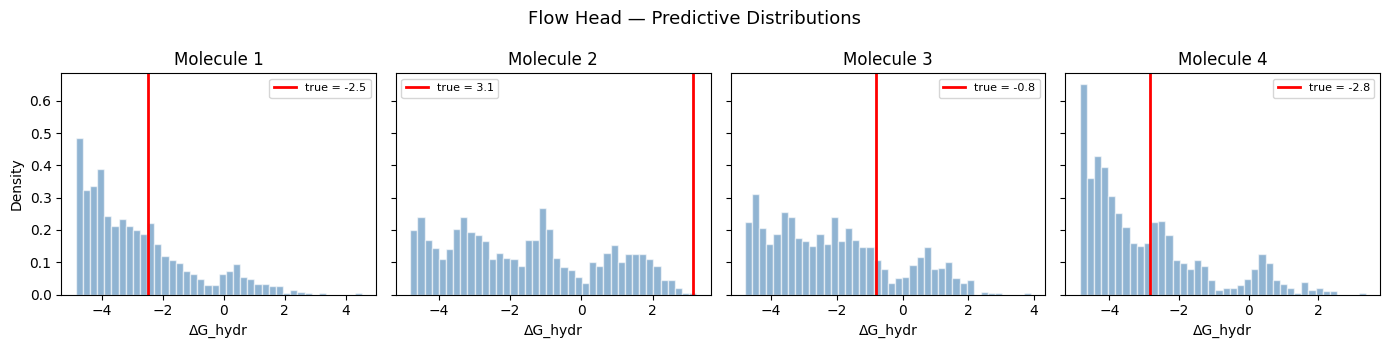

In [16]:
# Draw 1 000 samples per test molecule → shape (n_test, 1000, 1)
samples = flow.predict_flow(X_test, num_samples=1000)

# Visualise predictive distributions for first 4 test molecules
fig, axes = plt.subplots(1, min(4, len(y_test)), figsize=(14, 3.5), sharey=True)
for i, ax in enumerate(axes):
    s = samples[i, :, 0]
    ax.hist(s, bins=40, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    ax.axvline(y_test[i], color="red", lw=2, label=f"true = {y_test[i]:.1f}")
    ax.set_title(f"Molecule {i + 1}")
    ax.set_xlabel("ΔG_hydr")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.suptitle("Flow Head — Predictive Distributions", fontsize=13)
plt.tight_layout()
plt.show()

---

## 7½ — NODE + Flow Head: Tree Embeddings with Probabilistic Output

`NODERegressor` also supports **`head_type="flow"`**, which replaces the
final MLP head with a normalising flow.  This combines NODE's powerful
tree-based feature extraction with a full conditional density estimator:

```
  CheMeleon fp (2048-d)
        │
  ┌─────┴──────────────────────────────┐
  │  NODE: Oblivious Decision Trees     │
  │  (128 trees, depth 4, 1 layer)      │
  └─────┬──────────────────────────────┘
        │  tree embeddings
  ┌─────┴──────────────────────────────┐
  │  NICE Flow (2 transforms)          │
  │       p(y | tree_embed)            │
  └─────┬──────────────────────────────┘
        │
   point prediction + uncertainty
```

| Uncertainty source | Mechanism |
|---|---|
| **Epistemic** (knowledge) | Input dropout during MC-Dropout inference |
| **Aleatoric** (data) | Flow distribution width per molecule |
| **Total** | Combined from both sources |

> **Memory note:** NODE + Flow is the heaviest configuration in this notebook.
> We use a compact setup (128 trees, NICE flow) to fit in ≤ 8 GB RAM.
> For production use, scale up to 512+ trees with NSF transforms.

Re-initializing module because the following parameters were re-set: module__head_type, module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss     dur
-------  ------------  ------
      1       13.5850  1.4261
      2        3.0051  0.7057
      3        4.3628  0.7281
      4        3.8960  0.6799
      5        3.0311  0.9639
      6        2.9790  0.6991
      7        3.1315  0.7592
      8        2.8003  0.6803
      9        3.1149  0.6992
     10        2.5225  0.7955
     11        2.6682  0.6520
     12        2.3990  0.7224
     13        2.3987  1.3611
     14        2.2750  0.9162
     15        2.2150  0.7528
     16        2.2456  0.8494
     17        2.1079  0.7944
     18        2.0676  0.8904
     19        1.8995  0.7170
     20        1.8703  0.7820
     21        1.7375  0.7715
     22        2.3153  1.2475
     23        2.2537  1.3264
     24        1.7714  1.0478
     25        1.4189  1.1717
     26  

,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
0,-4.061899,12.022211,-0.169627,11.852584
1,-3.038451,79.404510,0.178741,79.583252
2,-2.936767,30.859547,-0.146477,30.713070
3,-3.390424,20.237696,-0.223416,20.014280
4,-3.560990,34.828091,-0.254597,34.573494
5,-3.271538,21.451267,-0.046026,21.405241
6,-3.181593,21.212301,-0.110172,21.102129
7,-3.323460,17.306847,-0.166283,17.140564
8,-3.409806,66.762733,0.003102,66.765839
9,-3.436447,53.418072,-0.018153,53.399918


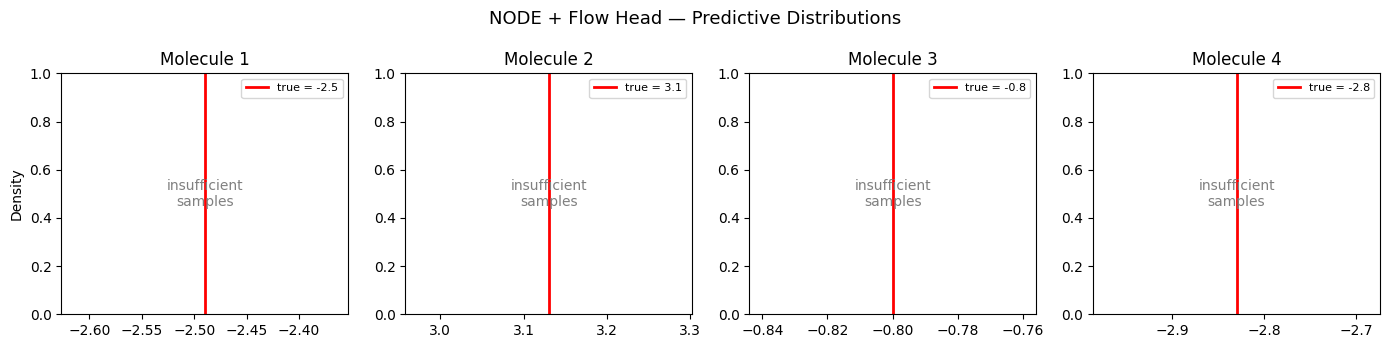

In [17]:
import gc, torch

# Free ALL earlier models + the fingerprinter to reclaim as much RAM as possible
for _v in ("mlp", "flow", "node", "fingerprinter", "factory"):
    if _v in dir():
        exec(f"del {_v}")
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# ── Train ────────────────────────────────────────────────────────────────
# Kept lightweight for 8 GB environments — scale up on larger machines.
node_flow = NODERegressor(
    num_trees=128,
    depth=4,
    num_layers=1,
    head_type="flow",
    flow_type="NICE",          # lighter than NSF, still learns p(y|x)
    flow_transforms=2,
    input_dropout=0.05,
    max_epochs=150,
    lr=0.005,
    batch_size=32,
)
node_flow.fit(X_train, y_train)

# ── Point predictions ────────────────────────────────────────────────────
y_pred_node_flow = node_flow.predict(X_test)
rmse_nf = root_mean_squared_error(y_test, y_pred_node_flow)
r2_nf = r2_score(y_test, y_pred_node_flow)
print(f"NODE+Flow  — RMSE: {rmse_nf:.3f} kcal/mol,  R²: {r2_nf:.3f}")
print(f"NODE+MLP   — RMSE: {rmse_node:.3f} kcal/mol,  R²: {r2_node:.3f}")
print(f"Flow Head  — RMSE: {rmse_flow:.3f} kcal/mol,  R²: {r2_flow:.3f}")

# ── Uncertainty ──────────────────────────────────────────────────────────
print("\n— Uncertainty estimates —")
unc_node_flow = node_flow.predict_uncertainty(X_test, num_samples=30)
display(unc_node_flow)

# ── Sample from the flow head ────────────────────────────────────────────
from scipy.stats import gaussian_kde

samples_nf = node_flow.predict_flow_head(X_test, num_samples=200)

fig, axes = plt.subplots(1, min(4, len(y_test)), figsize=(14, 3.5))
for i, ax in enumerate(axes):
    s = np.asarray(samples_nf[i]).ravel()  # works for 2-D or 3-D output
    # Need at least 2 unique values for KDE / histogram
    s = s[np.isfinite(s)]
    if len(s) < 2:
        ax.text(0.5, 0.5, "insufficient\nsamples", transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="grey")
        ax.axvline(y_test[i], color="red", lw=2, label=f"true = {y_test[i]:.1f}")
        ax.set_title(f"Molecule {i + 1}")
        ax.legend(fontsize=8)
        continue
    spread = max(np.ptp(s), 0.5)            # ensure visible x-range
    lo, hi = s.min() - 0.3 * spread, s.max() + 0.3 * spread
    # KDE handles very narrow distributions better than histograms
    try:
        if len(np.unique(s)) < 2:
            raise np.linalg.LinAlgError("constant samples")
        kde = gaussian_kde(s, bw_method=0.3)
        xs = np.linspace(lo, hi, 300)
        ax.fill_between(xs, kde(xs), alpha=0.5, color="darkorange")
        ax.plot(xs, kde(xs), color="darkorange", lw=1.5)
    except (np.linalg.LinAlgError, ValueError):
        ax.hist(s, bins=30, density=True, alpha=0.6, color="darkorange")
    ax.axvline(y_test[i], color="red", lw=2, label=f"true = {y_test[i]:.1f}")
    ax.axvline(np.median(s), color="darkorange", ls="--", lw=1.5, label=f"median = {np.median(s):.1f}")
    ax.set_xlim(lo, hi)
    ax.set_title(f"Molecule {i + 1}")
    ax.set_xlabel("ΔG_hydr")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.suptitle("NODE + Flow Head — Predictive Distributions", fontsize=13)
plt.tight_layout()
plt.show()

# ── Free the heavy model immediately ─────────────────────────────────────
del node_flow, samples_nf, unc_node_flow
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

---

## 9 — Experiment: Different MLP Architectures

Because the standalone heads are just scikit-learn estimators, it's easy to
sweep over architectures.

In [ ]:
import gc, torch

configs = {
    "narrow": {"hidden_dims": [128, 64], "dropout": 0.05},
    "wide": {"hidden_dims": [1024, 512, 256], "dropout": 0.10},
    "deep": {"hidden_dims": [256, 256, 256, 128], "dropout": 0.15},
}

results = []
for name, cfg in configs.items():
    m = MLPHeadRegressor(max_epochs=200, lr=0.003, **cfg)
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    results.append(
        {
            "config": name,
            "hidden_dims": cfg["hidden_dims"],
            "dropout": cfg["dropout"],
            "RMSE": root_mean_squared_error(y_test, yp),
            "R²": r2_score(y_test, yp),
        }
    )
    # Free the model immediately to avoid OOM on 8 GB machines
    del m
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

pd.DataFrame(results).round(3)

Re-initializing module because the following parameters were re-set: module__input_dim, module__output_dim.
Re-initializing criterion.
Re-initializing optimizer.
Re-initializing module because the following parameters were re-set: activation, batch_norm, dropout, hidden_dims, input_dim, output_dim.
Re-initializing criterion.
Re-initializing optimizer.
  epoch    train_loss    valid_loss      lr     dur
-------  ------------  ------------  ------  ------
      1       42.7247       16.7374  0.0030  0.2211
      2       29.9753       16.8213  0.0030  0.0064
      3       25.7454       16.8289  0.0030  0.0100
      4       23.3066       16.7516  0.0030  0.0101
      5       20.9276       16.5883  0.0030  0.0093
      6       18.8764       16.3368  0.0030  0.0163
      7       17.7749       16.0642  0.0030  0.0079
      8       16.5366       15.6284  0.0030  0.0072
      9       14.5658       15.0847  0.0030  0.0074
     10       14.7294       14.5366  0.0030  0.0093
     11       13.2379 

,config,hidden_dims,dropout,RMSE,R²
0,narrow,"[128, 64]",0.05,2.177,0.452
1,wide,"[1024, 512, 256]",0.10,2.574,0.234
2,deep,"[256, 256, 256, 128]",0.15,2.171,0.455


: 

---

## Summary

```
  SMILES  ───►  CheMeleon  ───►  Fingerprints (2048-d)  ───►  Head  ───►  ŷ + σ
                  (frozen)         (any featuriser)           (train)

                                                         ┌──────────────────────┐
                                                         │ MLPHead      → ŷ, σ_MC│
                                                         │ FlowHead    → p(y|x) │
                                                         │ NODE+MLP    → ŷ, σ_MC│
                                                         │ NODE+Flow   → p(y|x) │
                                                         └──────────────────────┘
```

| Step | What happens |
|---|---|
| **`CheMeleonFingerprintFactory`** | Downloads checkpoint, loads architecture + weights, builds fingerprint generator |
| **`CheMeleonFingerprinter`** | Sklearn transformer: SMILES → 2 048-dim pretrained molecular embeddings |
| **`MLPHeadRegressor`** | MLP + early stopping + LR schedule; `predict_uncertainty()` via MC Dropout |
| **`NODERegressor(head_type="mlp")`** | NODE trees + MLP head; MC Dropout uncertainty |
| **`NODERegressor(head_type="flow")`** | NODE trees + normalising flow; full p(y\|x) + epistemic/aleatoric uncertainty |
| **`FlowHeadRegressor`** | Standalone normalising flow; `predict_flow()` for full p(y\|x) sampling |
| **Plug-and-play** | Swap CheMeleon for **any** `(n, d)` featuriser — Morgan FPs, Uni-Mol, MolBERT, … |

All models return a **standardised 4-column DataFrame**:

```
mean_predictions │ knowledge_uncertainty │ data_uncertainty │ total_uncertainty
```

making them directly compatible with Mother's cross-validation, optimisation,
and reporting pipelines.